# Лабораторна робота  
## Аналіз впливу соціальних мереж на психологічні показники

### Мета роботи:
Дослідити залежності між використанням соціальних мереж та психологічними/поведінковими характеристиками.

### Завдання:
1. Завантажити та підготувати дані  
2. Очистити та обробити пропуски  
3. Побудувати різні типи графіків  
4. Проаналізувати результати  

### Теоретичні відомості:
Аналіз даних включає:
- Описову статистику
- Візуалізацію розподілів
- Аналіз кореляцій
- Виявлення залежностей між змінними


## 1. Імпорт бібліотек

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")


## 2. Завантаження даних

In [2]:
df = pd.read_csv("Teen_Mental_Health_Dataset.csv")
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


### Висновок
Дані успішно завантажено.

## 3. Обробка даних

In [3]:
# Заповнення пропусків
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

text_cols = df.select_dtypes(include="object").columns
for col in text_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   str    
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   str    
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   str    
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), str(3)
memory usage: 122.0 KB


/tmp/ipykernel_14483/2469125583.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include="object").columns


### Висновок
Пропуски оброблено.

## 4. Гістограма

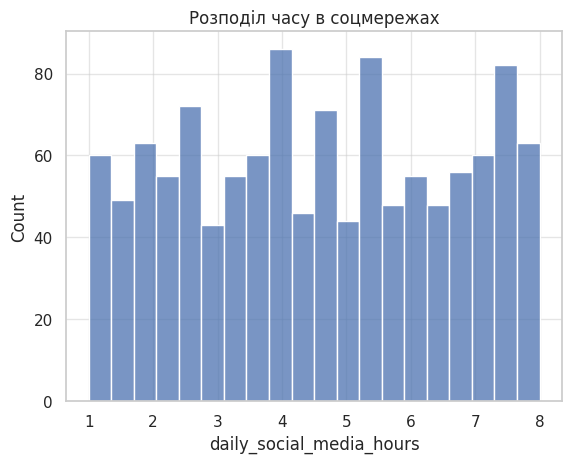

In [4]:
plt.figure()
sns.histplot(df["daily_social_media_hours"], bins=20)
plt.title("Розподіл часу в соцмережах")
plt.show()

### Висновок
Показує розподіл часу користування.

## 5. KDE

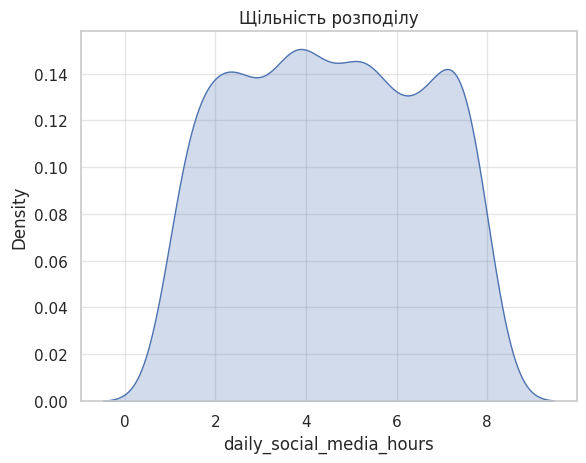

In [5]:
sns.kdeplot(df["daily_social_media_hours"], fill=True)
plt.title("Щільність розподілу")
plt.show()

### Висновок
Плавна оцінка розподілу.

## 6. Стовпчикова діаграма

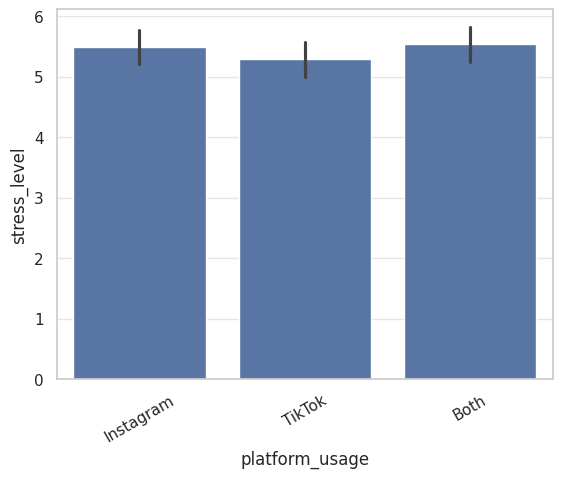

In [6]:
sns.barplot(data=df, x="platform_usage", y="stress_level")
plt.xticks(rotation=30)
plt.show()

### Висновок
Порівняння категорій.

## 7. Boxplot

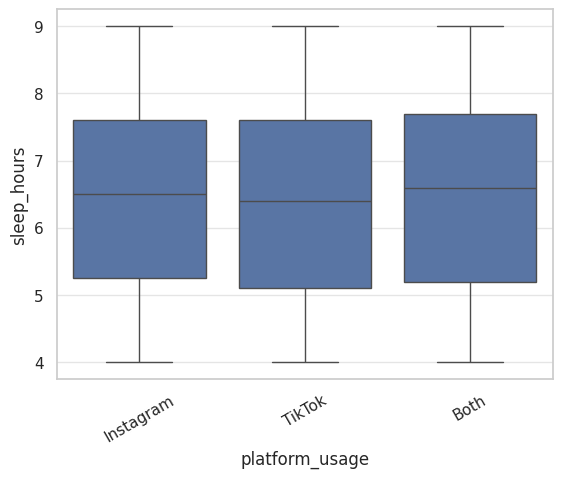

In [7]:
sns.boxplot(data=df, x="platform_usage", y="sleep_hours")
plt.xticks(rotation=30)
plt.show()

### Висновок
Аналіз викидів.

## 8. Кругова діаграма

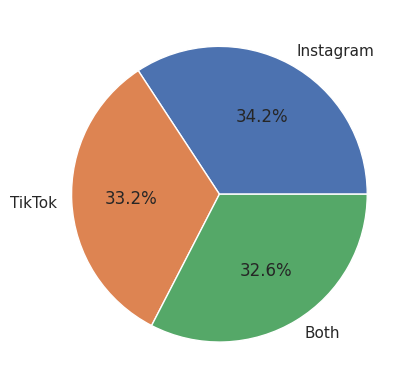

In [8]:
df["platform_usage"].value_counts().head(5).plot.pie(autopct='%1.1f%%')
plt.ylabel("")
plt.show()

### Висновок
Структура використання платформ.

## 9. Scatter plot

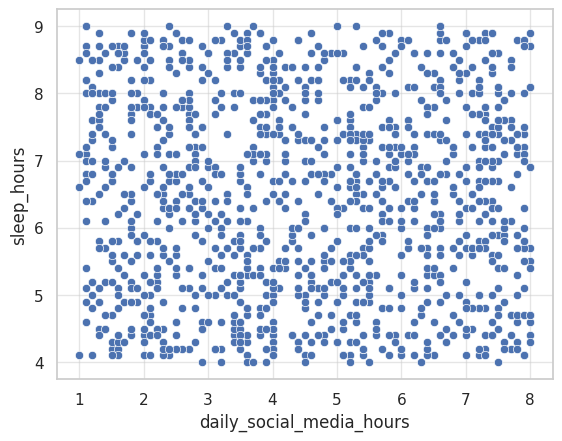

In [9]:
sns.scatterplot(data=df, x="daily_social_media_hours", y="sleep_hours")
plt.show()

### Висновок
Залежність слабка.

## 10. Лінійний графік

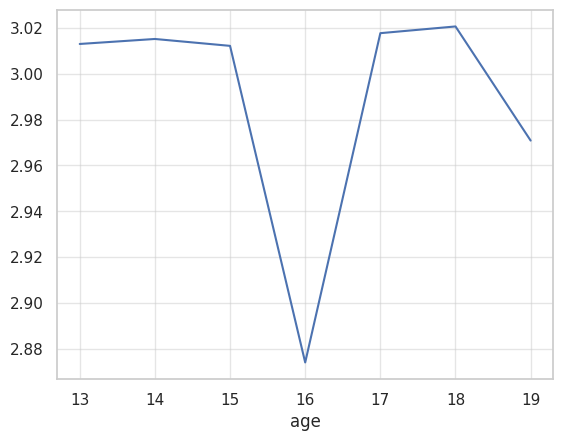

In [10]:
trend = df.groupby("age")["academic_performance"].mean()
trend.plot()
plt.show()

### Висновок
Аналіз тренду.

## 11. Кореляційна матриця

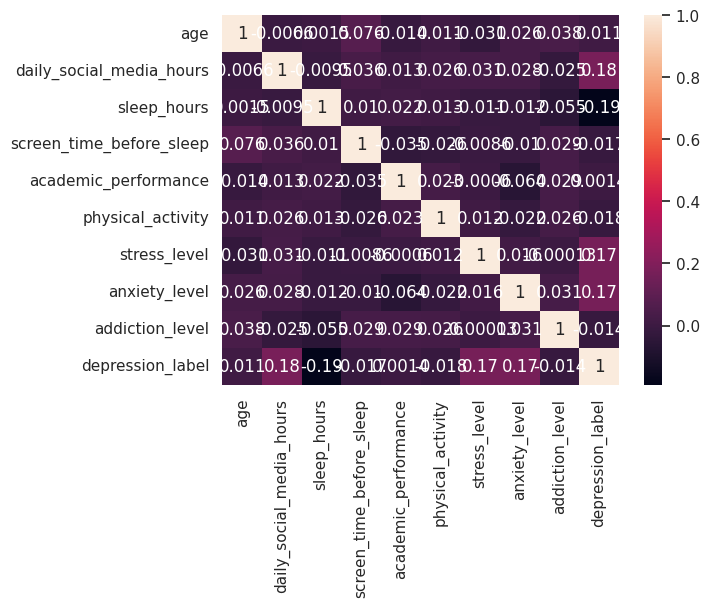

In [11]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.show()

### Висновок
Кореляції слабкі.